In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.base import clone

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RNG = 42

Part 2 preprocessing

In [25]:
df=pd.read_csv("cleaned_data.csv", parse_dates=["Ticket Date"])

y_reg=df["Resolution Time (Days)"].copy()
SLA_DAYS=6
y_clf=(df["Resolution Time (Days)"] > SLA_DAYS).astype(int)

df["ticket_month"]=df["Ticket Date"].dt.month
df["ticket_dayofweek"]=df["Ticket Date"].dt.dayofweek
df["agent_assigned"]=df["Agent ID"].notna().astype(int)

LEAKAGE_OR_ID_COLS=[
    "ID Ticket", "Ticket Date", "Employee ID", "Agent ID",
    "Full Name", "Email", "Year of Birth", "Month of Birth", "Day of Birth",
    "Severity", "Priority", "Resolution Time (Days)", "Satisfaction Rate",
]
X=df.drop(columns=LEAKAGE_OR_ID_COLS)

for col in ["Priority_level", "Agent_age"]:
    X[col]=X[col].fillna(X[col].median())

X=pd.get_dummies(X, columns=["Request Category", "Issue Type"], drop_first=True)

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RNG
)

scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled= pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"X_train_scaled: {X_train_scaled.shape}, X_test_scaled: {X_test_scaled.shape}")
print(f"Features: {X.columns.tolist()}")


X_train_scaled: (77998, 10), X_test_scaled: (19500, 10)
Features: ['Priority_level', 'Severity_level', 'Agent_age', 'ticket_month', 'ticket_dayofweek', 'agent_assigned', 'Request Category_Login Access', 'Request Category_Software', 'Request Category_System', 'Issue Type_IT Request']


Task 1

In [26]:
tree_unconstrained=DecisionTreeClassifier(random_state=RNG)
tree_unconstrained.fit(X_train_scaled, y_clf_train)

train_acc_unc=accuracy_score(y_clf_train, tree_unconstrained.predict(X_train_scaled))
test_acc_unc=accuracy_score(y_clf_test, tree_unconstrained.predict(X_test_scaled))
print(f"Training accuracy: {train_acc_unc:.4f}")
print(f"Test accuracy:     {test_acc_unc:.4f}")
print(f"Train-test gap:    {train_acc_unc - test_acc_unc:.4f}")

Training accuracy: 0.8856
Test accuracy:     0.7248
Train-test gap:    0.1608


Task 2

In [27]:
tree_controlled=DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=RNG)
tree_controlled.fit(X_train_scaled, y_clf_train)

train_acc_ctrl=accuracy_score(y_clf_train, tree_controlled.predict(X_train_scaled))
test_acc_ctrl=accuracy_score(y_clf_test, tree_controlled.predict(X_test_scaled))
print(f"Training accuracy: {train_acc_ctrl:.4f}")
print(f"Test accuracy:     {test_acc_ctrl:.4f}")
print(f"Train-test gap:    {train_acc_ctrl - test_acc_ctrl:.4f}")

Training accuracy: 0.7704
Test accuracy:     0.7693
Train-test gap:    0.0011


Task 3

In [28]:
tree_gini=DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=RNG)
tree_gini.fit(X_train_scaled, y_clf_train)
test_acc_gini=accuracy_score(y_clf_test, tree_gini.predict(X_test_scaled))

tree_entropy=DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=RNG)
tree_entropy.fit(X_train_scaled, y_clf_train)
test_acc_entropy=accuracy_score(y_clf_test, tree_entropy.predict(X_test_scaled))

print(f"Gini test accuracy:    {test_acc_gini:.4f}")
print(f"Entropy test accuracy: {test_acc_entropy:.4f}")

Gini test accuracy:    0.7692
Entropy test accuracy: 0.7693


Task 4

In [29]:
rf=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RNG)
rf.fit(X_train_scaled, y_clf_train)

rf_train_acc=accuracy_score(y_clf_train, rf.predict(X_train_scaled))
rf_test_acc=accuracy_score(y_clf_test, rf.predict(X_test_scaled))
rf_test_auc=roc_auc_score(y_clf_test, rf.predict_proba(X_test_scaled)[:, 1])

print(f"Training accuracy: {rf_train_acc:.4f}")
print(f"Test accuracy:     {rf_test_acc:.4f}")
print(f"Test ROC-AUC:      {rf_test_auc:.4f}")

feature_importance=pd.DataFrame({
    "feature": X.columns, "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
print("\nTop 5 features by importance:")
display(feature_importance.head(5))


Training accuracy: 0.7809
Test accuracy:     0.7754
Test ROC-AUC:      0.8497

Top 5 features by importance:


,feature,importance
6,Request Category_Login Access,0.494005
9,Issue Type_IT Request,0.133960
0,Priority_level,0.125523
8,Request Category_System,0.105710
7,Request Category_Software,0.063452


Task 4a

In [30]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RNG)
gb.fit(X_train_scaled, y_clf_train)

gb_train_acc = accuracy_score(y_clf_train, gb.predict(X_train_scaled))
gb_test_acc = accuracy_score(y_clf_test, gb.predict(X_test_scaled))
gb_test_auc = roc_auc_score(y_clf_test, gb.predict_proba(X_test_scaled)[:, 1])

print(f"Training accuracy: {gb_train_acc:.4f}")
print(f"Test accuracy:     {gb_test_acc:.4f}")
print(f"Test ROC-AUC:      {gb_test_auc:.4f}")



Training accuracy: 0.7750
Test accuracy:     0.7756
Test ROC-AUC:      0.8496


Task 4b

In [31]:
lowest5=feature_importance.tail(5)["feature"].tolist()
print(f"5 lowest-importance features: {lowest5}")

X_train_reduced=X_train_scaled.drop(columns=lowest5)
X_test_reduced=X_test_scaled.drop(columns=lowest5)

rf_reduced=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RNG)
rf_reduced.fit(X_train_reduced, y_clf_train)
rf_reduced_test_auc = roc_auc_score(y_clf_test,rf_reduced.predict_proba(X_test_reduced)[:, 1])

print(f"Full-model test ROC-AUC (all {X_train_scaled.shape[1]} features):    {rf_test_auc:.4f}")
print(f"Reduced-model test ROC-AUC ({X_train_reduced.shape[1]} features):     {rf_reduced_test_auc:.4f}")
print(f"AUC change: {rf_reduced_test_auc - rf_test_auc:+.4f}")


5 lowest-importance features: ['Agent_age', 'Severity_level', 'ticket_month', 'ticket_dayofweek', 'agent_assigned']
Full-model test ROC-AUC (all 10 features):    0.8497
Reduced-model test ROC-AUC (5 features):     0.8433
AUC change: -0.0064


Task 5

In [32]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

models_for_cv={
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RNG),
    "Decision Tree (max_depth=5)": DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=RNG),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RNG),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RNG),
}

cv_results=[]
for name, model in models_for_cv.items():
    scores=cross_val_score(model, X_train_scaled, y_clf_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append((name, scores.mean(), scores.std()))
    print(f"{name}: mean AUC = {scores.mean():.4f}, std = {scores.std():.4f}")

cv_table= pd.DataFrame(cv_results, columns=["Model", "Mean CV AUC", "Std CV AUC"])
print("\nCross-validated comparison table:")
display(cv_table)


Logistic Regression: mean AUC = 0.8314, std = 0.0033
Decision Tree (max_depth=5): mean AUC = 0.8387, std = 0.0031
Random Forest: mean AUC = 0.8461, std = 0.0028
Gradient Boosting: mean AUC = 0.8472, std = 0.0024

Cross-validated comparison table:


,Model,Mean CV AUC,Std CV AUC
0,Logistic Regression,0.831424,0.003346
1,Decision Tree (max_depth=5),0.838662,0.003139
2,Random Forest,0.846115,0.002845
3,Gradient Boosting,0.847246,0.002446


Task 6

In [33]:
X_raw=df.drop(columns=LEAKAGE_OR_ID_COLS)
X_raw=pd.get_dummies(X_raw, columns=["Request Category", "Issue Type"], drop_first=True)
X_train_raw, X_test_raw=X_raw.loc[X_train.index], X_raw.loc[X_test.index]

pipeline=make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(random_state=RNG),
)

param_grid={
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5],
}
n_configs=1
for v in param_grid.values():
    n_configs*=len(v)
print(f"Total parameter configurations: {n_configs} (x 5 folds = {n_configs*5} total fits)")

grid_search=GridSearchCV(
    pipeline, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG),
    scoring="roc_auc", n_jobs=-1,
)
grid_search.fit(X_train_raw, y_clf_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV score (mean AUC): {grid_search.best_score_:.4f}")

best_pipeline= grid_search.best_estimator_
best_pipeline_test_auc=roc_auc_score(y_clf_test, best_pipeline.predict_proba(X_test_raw)[:, 1])
print(f"Best pipeline test-set AUC: {best_pipeline_test_auc:.4f}")


Total parameter configurations: 18 (x 5 folds = 90 total fits)

Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}
Best CV score (mean AUC): 0.8462
Best pipeline test-set AUC: 0.8498


Task 7

fraction=0.2, n=15599: train AUC=0.8864, test AUC=0.8468
fraction=0.4, n=31199: train AUC=0.8684, test AUC=0.8482
fraction=0.6, n=46798: train AUC=0.8626, test AUC=0.8486
fraction=0.8, n=62398: train AUC=0.8602, test AUC=0.8491
fraction=1.0, n=77998: train AUC=0.8581, test AUC=0.8498

Learning curve table:


,Training fraction,N rows,Training AUC,Test AUC
0,0.2,15599,0.886378,0.846822
1,0.4,31199,0.868427,0.848209
2,0.6,46798,0.862649,0.848574
3,0.8,62398,0.860154,0.849124
4,1.0,77998,0.858109,0.849775


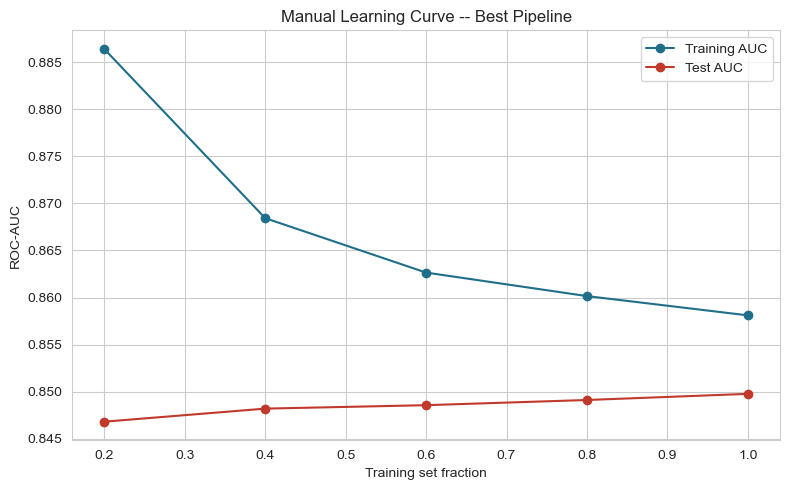

In [34]:
learning_curve_rows=[]
for f in [0.2, 0.4, 0.6, 0.8, 1.0]:
    n_rows=int(f * len(X_train_raw))
    X_subset=X_train_raw.iloc[:n_rows]
    y_subset=y_clf_train.iloc[:n_rows]

    pipeline_f=clone(best_pipeline)
    pipeline_f.fit(X_subset, y_subset)

    train_auc=roc_auc_score(y_subset, pipeline_f.predict_proba(X_subset)[:, 1])
    test_auc=roc_auc_score(y_clf_test, pipeline_f.predict_proba(X_test_raw)[:, 1])
    learning_curve_rows.append((f, n_rows, train_auc, test_auc))
    print(f"fraction={f}, n={n_rows}: train AUC={train_auc:.4f}, test AUC={test_auc:.4f}")

learning_curve_table=pd.DataFrame(
    learning_curve_rows, columns=["Training fraction", "N rows", "Training AUC", "Test AUC"]
)
print("\nLearning curve table:")
display(learning_curve_table)

plt.figure(figsize=(8, 5))
plt.plot(learning_curve_table["Training fraction"], learning_curve_table["Training AUC"],
         marker="o", label="Training AUC", color="#1f6f8b")
plt.plot(learning_curve_table["Training fraction"], learning_curve_table["Test AUC"],
         marker="o", label="Test AUC", color="#c0392b")
plt.xlabel("Training set fraction")
plt.ylabel("ROC-AUC")
plt.title("Manual Learning Curve -- Best Pipeline")
plt.legend()
plt.tight_layout()
plt.show()


Task 8

In [35]:
joblib.dump(best_pipeline, "best_model.pkl")
print("Saved best_pipeline to best_model.pkl")

loaded_model=joblib.load("best_model.pkl")

hand_crafted_rows=pd.DataFrame([
    {  
        "Priority_level": 3, "Severity_level": 2, "Agent_age": 35,
        "ticket_month": 6, "ticket_dayofweek": 2, "agent_assigned": 1,
        "Request Category_Login Access": 1, "Request Category_Software": 0,
        "Request Category_System": 0, "Issue Type_IT Request": 0,
    },
    {  
        "Priority_level": 0, "Severity_level": 3, "Agent_age": 35,
        "ticket_month": 11, "ticket_dayofweek": 4, "agent_assigned": 0,
        "Request Category_Login Access": 0, "Request Category_Software": 0,
        "Request Category_System": 0, "Issue Type_IT Request": 1,
    },
])[X_train_raw.columns]

preds = loaded_model.predict(hand_crafted_rows)
probas = loaded_model.predict_proba(hand_crafted_rows)[:, 1]
print("\nPredictions on hand-crafted rows:")
for i, (p, prob) in enumerate(zip(preds, probas)):
    label = "SLA BREACH" if p == 1 else "No breach"
    print(f"  Row {i+1}: predicted={label}, P(breach)={prob:.3f}")


Saved best_pipeline to best_model.pkl

Predictions on hand-crafted rows:
  Row 1: predicted=No breach, P(breach)=0.004
  Row 2: predicted=SLA BREACH, P(breach)=0.575


Task 9

In [36]:
summary_rows = []
for name, mean_auc, std_auc in cv_results:
    if name == "Logistic Regression":
        test_auc_val = roc_auc_score(y_clf_test, LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RNG
        ).fit(X_train_scaled, y_clf_train).predict_proba(X_test_scaled)[:, 1])
    elif name == "Decision Tree (max_depth=5)":
        test_auc_val = roc_auc_score(y_clf_test, tree_controlled.predict_proba(X_test_scaled)[:, 1])
    elif name == "Random Forest":
        test_auc_val = rf_test_auc
    elif name == "Gradient Boosting":
        test_auc_val = gb_test_auc
    summary_rows.append((name, mean_auc, std_auc, test_auc_val))

summary_rows.append(("Tuned RF Pipeline (GridSearchCV best)", grid_search.best_score_, np.nan, best_pipeline_test_auc))

summary_table = pd.DataFrame(summary_rows, columns=["Model", "5-fold CV Mean AUC", "5-fold CV Std AUC", "Test-set AUC"])
print("Final summary comparison table:")
display(summary_table)


Final summary comparison table:


,Model,5-fold CV Mean AUC,5-fold CV Std AUC,Test-set AUC
0,Logistic Regression,0.831424,0.003346,0.834316
1,Decision Tree (max_depth=5),0.838662,0.003139,0.840969
2,Random Forest,0.846115,0.002845,0.849748
3,Gradient Boosting,0.847246,0.002446,0.849601
4,Tuned RF Pipeline (GridSearchCV best),0.846167,NaN,0.849775
